In [1]:
###Import all relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
#Load the data
df = pd.read_csv('/Users/nosipholyanahsibanda/Downloads/insurance.csv')
df.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [3]:
### Check for any missing values in the dataset 
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


The data is checked for any missing values that might affect the quality of the data

In [4]:
## Look at the data types of all our fields
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [5]:
## Look at the information and properties of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [6]:
### Check for duplicated rows in the dataset 

df.duplicated().sum()

np.int64(1)

In [7]:
#Show the row that has been duplicated
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
# Check if the duplicated row is an exact duplicate by showing both the original row and the duplicated row
# This will help us confirm if the duplicated value is indeed a duplicate
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


## Interpretation

The dataset is first checked for the presence of duplicates then the returned duplicated row is compared to the original row to confirm that they are indeed duplicated before proceeding to delete the duplicated row.


In [9]:
#Delete the confirmed duplicated row
df = df.drop_duplicates()

In [10]:
### Confirm if the duplicated row has infact been deleted

df.duplicated().sum()

np.int64(0)

In [11]:
## Confirm the new size of the dataset after the duplicated row has been deleted
df.shape

(1337, 7)

Duplicate observations: One duplicated observation was identified and removed. Removing the duplicated cell with ensure there is no additional influence during the training and testing of the model. After duplication removal the dataset now has 1337 observations and 7 variables

In [12]:
### Look at the properties of the data
print(df.describe())

               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


## Interpretation
The dataset contained 1338 observations (1337 after removing the duplicate). The average age is approximately 39 years, while the the average BMI is 30.66. On average, individuals have 1 child. The average medical charge is approximately R13270. The summary also shows that age ranges from 18 to 64, BMI ranges from 15.96 to 53.13, and charges range from about R1122 to R36770.

In [13]:
### Check the unique categories in categorical variable 
print("sex: ", df['sex'].unique())
print("smoker: ", df['smoker'].unique())
print("region: ", df['region'].unique())


      
    

sex:  <ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
smoker:  <ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str
region:  <ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [14]:
### Check for the frequency of each categorical value
print(df['sex'].value_counts())
print()
print(df['smoker'].value_counts())
print()
print(df['region'].value_counts())
print()

sex
male      675
female    662
Name: count, dtype: int64

smoker
no     1063
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64



## Interpretation

This counts the values for all the categories in the caterogical fields which are the sex, smoker and region, and it also shows the data type of the entries.

In [15]:
###Check for the minimum and maximum values of the numerical values 
print("age:", df['age'].min(), "-",df['age'].max())
print("bmi:", df['bmi'].min(), "-",df['bmi'].max())
print("children:", df['children'].min(), "-",df['children'].max())
print("charges:", df['charges'].min(), "-",df['charges'].max())

age: 18 - 64
bmi: 15.96 - 53.13
children: 0 - 5
charges: 1121.8739 - 63770.42801


## Interpretation 
This tell us that the minimum age of people covered within in the age insurance is 18 and the maximum age is 64 years old. 
It also shows that the lowest bmi is 15.96 while the maximum bmi is 53.13
The minimum number of children in a household/family is 0 children and the maximum is five children per family.
The minimum charges is 1121.8739 and the maximum is 63770.42801

In [16]:
## Perform descriptive statistics for all numerical fields 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


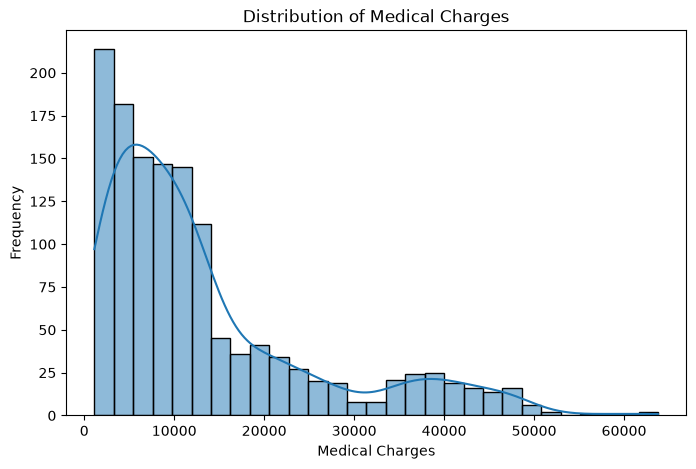

In [17]:
#Plot distributions of medical charges 
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Medical Charges")
plt.xlabel("Medical Charges")
plt.ylabel('Frequency')
plt.show()
          

## Interpretation 
The visual shows that most people have lower charges, while a smaller number have much higher charges. This shows that medical charges differ a lot between people. 

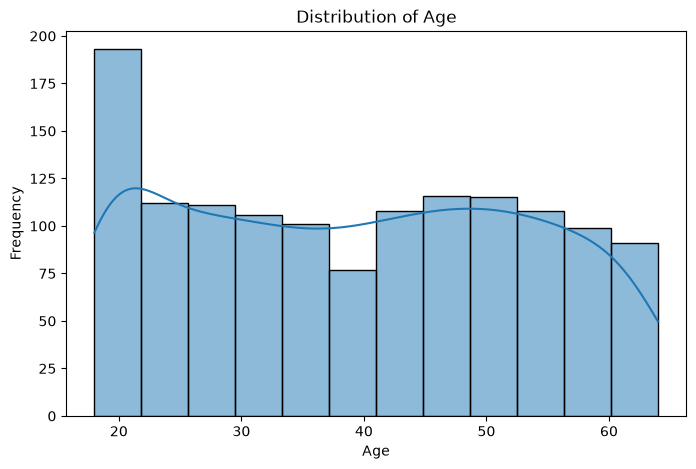

In [18]:
# Distribution of age 
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel('Frequency')
plt.show()


## Interpretation

The ages range from 18 to 64 year old, with younger customers from age 18 to 22 occurring being more than the other age groups.

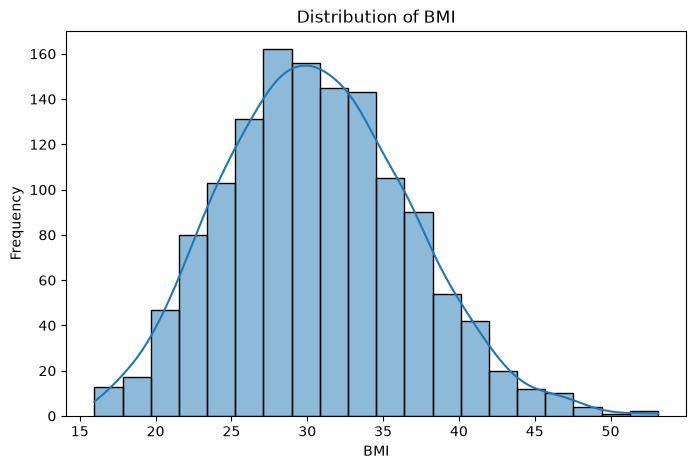

In [19]:
#Distribution of BMI

plt.figure(figsize=(8, 5))
sns.histplot(df["bmi"], bins=20, kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel('Frequency')
plt.show()

## Interpretation 
The BMI distribution shows that the relationship between BMI and medical charges appears weak.

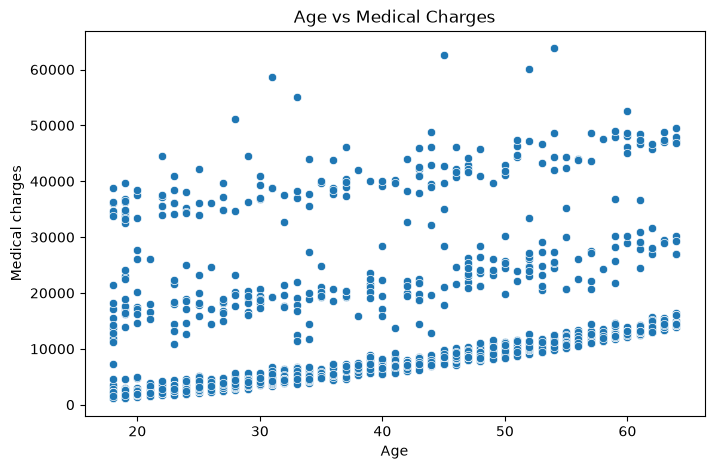

In [20]:
#The relationship between age and medical charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges')
plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel('Medical charges')
plt.show()

## Interpretation 

Medical charges increase as age increases, which indicates a positive relationship between age and medical charges.


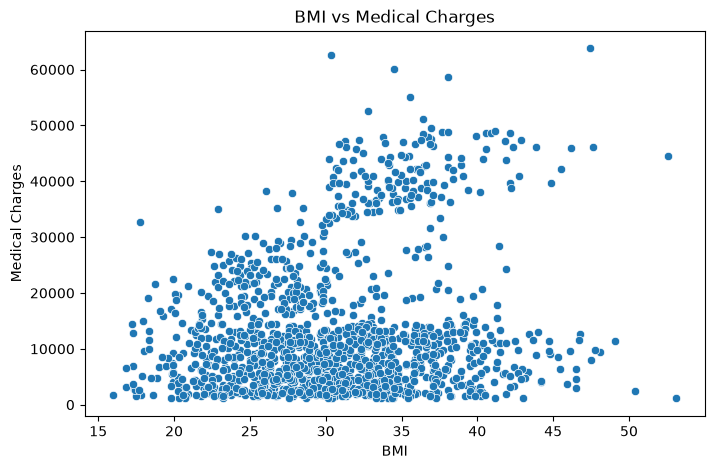

In [21]:
#The relationship between BMI and medical charges
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel('Medical Charges')
plt.show()

## Interpretation 
The relationship between BMI and medical charges appears to be weak, although higher medical charges are more prevalent among customers with BMI values around 30 to 40.

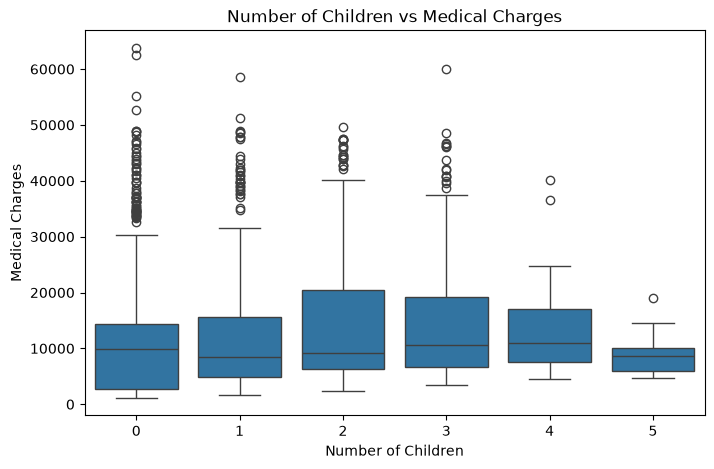

In [22]:
#The relationship between children and medical charges
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='children', y='charges')
plt.title("Number of Children vs Medical Charges")
plt.xlabel("Number of Children")
plt.ylabel('Medical Charges')
plt.show()

## Interpretation

Medical charges vary across the different numbers of children, but there is no clear trend or relationship. 

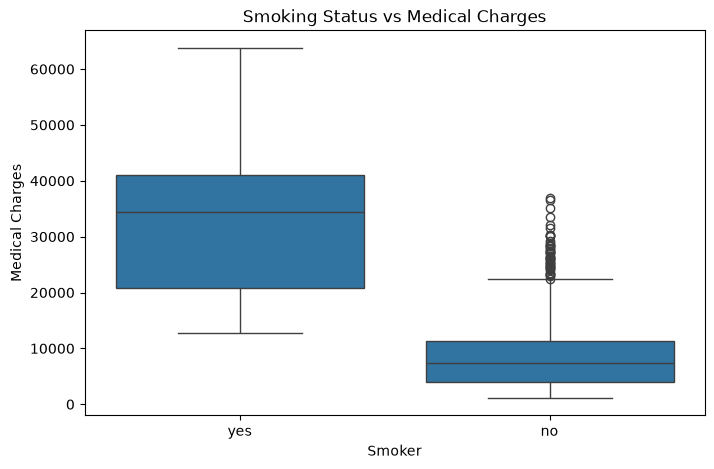

In [23]:
###Medical charges by smoking status
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges')
plt.title("Smoking Status vs Medical Charges")
plt.xlabel("Smoker")
plt.ylabel('Medical Charges')
plt.show()

## Interpretation 

Smokers have significantly higher medical charges than non-smokers which implies that smoking status is an important predictor of medical charges.

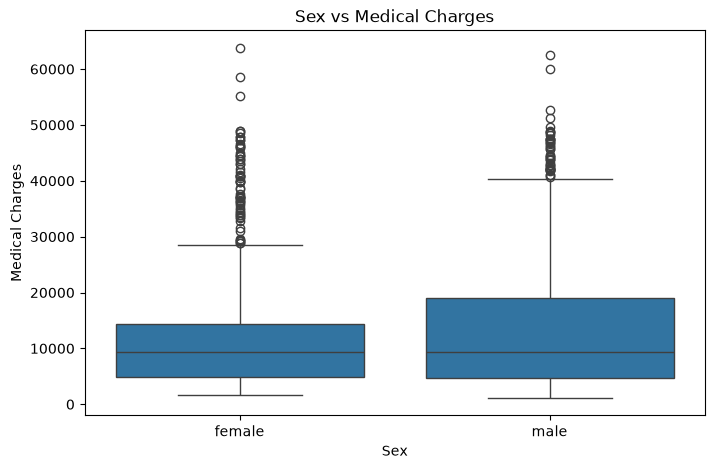

In [24]:
###Medical charges by sex
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sex', y='charges')
plt.title("Sex vs Medical Charges")
plt.xlabel("Sex")
plt.ylabel('Medical Charges')
plt.show()

## Interpretation 

It appears that sex does have a strong relationship with medical charges, but there is a visible overlap between the two groups of sex. 

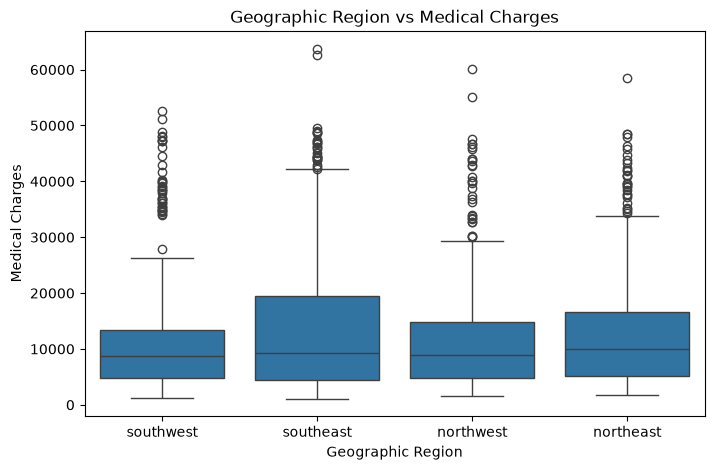

In [25]:
###Medical charges by geographic region
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='region', y='charges')
plt.title("Geographic Region vs Medical Charges")
plt.xlabel("Geographic Region")
plt.ylabel('Medical Charges')
plt.show()

## Interpretation 

Medical charges are almost similar across the different geographic regions with some differences. 

<function matplotlib.pyplot.show(close=None, block=None)>

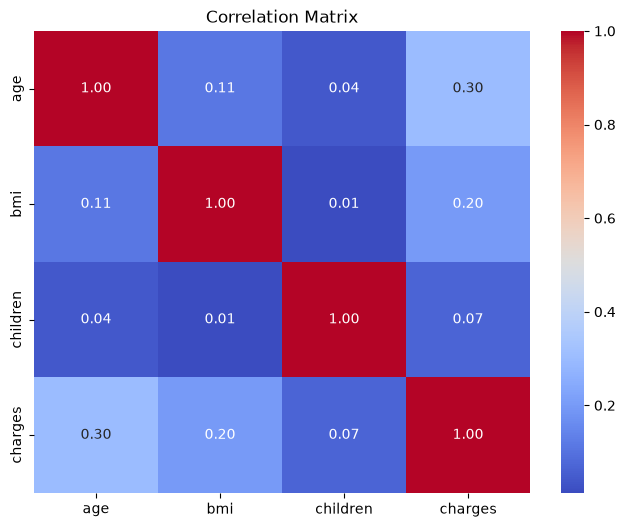

In [26]:
# Correlation Matrix for numerical variables
correlation_matrix = df[['age', 'bmi', 'children', 'charges']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show

## Interpretation 

This shows a positive relationship between age and medical charges(0.30), while BMI has a weaker positive relationship (0.20). The relationship between the number of children and charges is very weak (0.07).

In [27]:
# Define predictor variables and target variables
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

In [28]:
# Split dataset into training and testing data sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.20,
    random_state=42
)

In [29]:
# Identify numerical and categorical variables
numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

In [30]:
# Convert categorical variables into numbers

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [31]:
# Create the Linear Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [32]:
#Train the Model 
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the ou

In [33]:
#Check tranformation results
model.named_steps['preprocessor'].get_feature_names_out()

array(['categorical__sex_male', 'categorical__smoker_yes',
       'categorical__region_northwest', 'categorical__region_southeast',
       'categorical__region_southwest', 'remainder__age',
       'remainder__bmi', 'remainder__children'], dtype=object)

In [34]:
#Make prediction based of the testing data
y_pred = model.predict(X_test)

In [35]:
# Comparing actual charges to predicted charges 

comparison = pd.DataFrame({
    'Actual Charges':y_test.values, 
    'Predicted Charges': y_pred
})
comparison.head(10)

,Actual Charges,Predicted Charges
0,8688.85885,8143.693884
1,5708.86700,5737.115683
2,11436.73815,14369.314876
3,38746.35510,31745.513636
4,4463.20510,8962.386657
5,9304.70190,13149.722353
6,38511.62830,30446.760679
7,2150.46900,1453.288813
8,7345.72660,10633.018402
9,10264.44210,11318.943794


In [36]:
#Calculating the R-squared 
r2 = r2_score(y_test, y_pred)

print("R-squared:", r2)

R-squared: 0.8069287081198011


## Interpretation

The R2 is 0.8069, which shows that about 80.7% of the variation in medical charges is explained by the variables in the model.

In [37]:
#Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4177.045561036326


## Interpretation
The MAE is 4177.05, Which shows that the models predictions are wrong by R4177.05 on average.

In [38]:
#Calculate Root Mean squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5956.342894363588


## Interpretation 

The RMSE is 5956.32, which gives weight to larger errors, so the higher value some predictions have bigger errors.

In [39]:
# Show the model evaluation metrics
print("Model Evaluation")
print("-------------------")
print("R-squared:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Model Evaluation
-------------------
R-squared: 0.8069287081198011
MAE: 4177.045561036326
RMSE: 5956.342894363588


### Model Evaluation

The first multiple linear regression model was evaluated using R-squared, Mean Absolute Error (MAE), and Root Mean Squared Error(RMSE).
R-squared show how much of the variation in the medical charges can be explained by the model. MAE shows the average absolute difference between the predicted and actual charges, while the RMSE gives a greater weight to larger prediction errors. 

The model achieved an R-squared of 0.8069, an MAE of 4177.05 and a RMSE of 5956.34.

In [40]:
### Getting the names of the features used by the regression model
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
feature_names

array(['categorical__sex_male', 'categorical__smoker_yes',
       'categorical__region_northwest', 'categorical__region_southeast',
       'categorical__region_southwest', 'remainder__age',
       'remainder__bmi', 'remainder__children'], dtype=object)

In [41]:
# Get the regression coefficients 
coefficients = model.named_steps['regressor'].coef_

coefficient_table = pd.DataFrame({
    'Feature': feature_names, 
    'Coefficient': coefficients 
})
coefficient_table

,Feature,Coefficient
0,categorical__sex_male,-101.542054
1,categorical__smoker_yes,23077.764593
2,categorical__region_northwest,-391.761455
3,categorical__region_southeast,-838.919616
4,categorical__region_southwest,-659.139752
5,remainder__age,248.210720
6,remainder__bmi,318.701441
7,remainder__children,533.009989


In [42]:
#Show the model intercept
intercept = model.named_steps['regressor'].intercept_

print("Intercept:", intercept)

Intercept: -11092.652295945965


In [43]:
#Sort coefficients from smallest to largest
coefficient_table.sort_values('Coefficient')

,Feature,Coefficient
3,categorical__region_southeast,-838.919616
4,categorical__region_southwest,-659.139752
2,categorical__region_northwest,-391.761455
0,categorical__sex_male,-101.542054
5,remainder__age,248.210720
6,remainder__bmi,318.701441
7,remainder__children,533.009989
1,categorical__smoker_yes,23077.764593


## Interpretation of Model Coefficients 

The regression coefficients indicate the estimate change in medical charges associated with each predictor, while holding the other variables constant. 

Positive coefficients indicate an increase in predicted charges, while negative coefficients indicate a decrease relative to the relevant reference category

In [44]:
##Calculate prediction errors (residuals)
residuals = y_test - y_pred

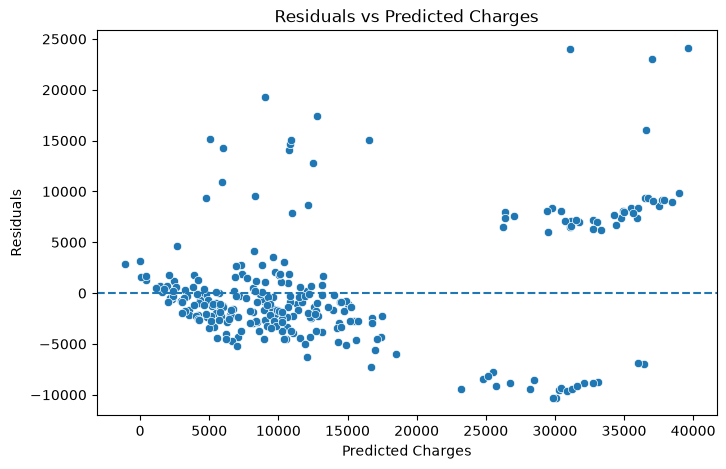

In [45]:
## Residuals vs predicted values 
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, linestyle='--')
plt.title('Residuals vs Predicted Charges')
plt.xlabel('Predicted Charges')
plt.ylabel('Residuals')
plt.show()

## Interpretation 

The residuals are concentrated around zero but the plot shows some variation and a noticeable pattern as predicted charges increase.

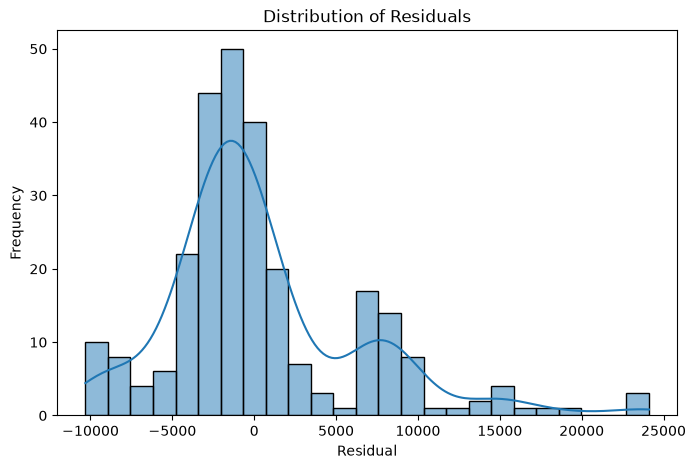

In [46]:
# The Distribution of residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

### Residual Analysis 

The residual plots were examined to assess whether the linear regression model produced errors that were reasonably randomly distributed. 
The residuals are mostly concentrated around zero which shows that the models predictions are close to the observed values, the distribution shows a positive skew with some large positive residuals. 


## Feature Selection

Feature selection was conducted to assess the contribution and statistical significance of the predictor variables. P-values from an Ordinary Least Squares (OLS) regression model were used as supporting evidence when evaluating the predictors.
The variables considered were age, sex, BMI, number of children, smoking status, and geographic region, as these variables are directly relevant to the client's requirement for lifestyle- and region-based medical aid pricing.

In [47]:
import statsmodels.formula.api as smf

train_data = pd.concat([X_train, y_train], axis=1)

ols_model = smf.ols(
'charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)',
data=train_data
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     358.1
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          4.94e-295
Time:                        20:05:57   Log-Likelihood:                -10831.
No. Observations:                1069   AIC:                         2.168e+04
Df Residuals:                    1060   BIC:                         2.172e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.10

### Feature Selection Findings

The OLS results were used to assess the statistical significance of the predictor variables. The results indicate that some predictors have a stronger statistical relationship with medical charges than others.

However, predictors were not removed solely based on statistical significance. The final feature set was also considered in relation to the client's requirements, which specifically identified age, sex, BMI, children, smoking habits and geographic region as factors for determining medical aid costs. Therefore, these variables were retained for the predictive model.

## Model Interpretation

The multiple linear regression model estimates medical insurance charges using age, sex, BMI, number of children, smoking status and geographic region.
The regression model can be represented as:
Charges = β₀ + β₁(Age) + β₂(BMI) + β₃(Children) + β₄(Sex) + β₅(Smoker) + β₆(Region) + ε
Because sex, smoking status and region are categorical variables, they were converted into numerical variables using one-hot encoding.

## Model Evaluation

The model was evaluated using R², Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

R² measures the proportion of variation in medical charges explained by the model. A higher R² indicates that the model explains more of the variation in the target variable.

MAE represents the average absolute difference between the actual and predicted medical charges. Lower values indicate more accurate predictions.

RMSE measures the square root of the average squared prediction error. Lower values indicate better predictive performance, while larger errors are penalised more strongly than with MAE.

### Evaluation Results

The model achieved an R² score of 0.8069, which shows that about 80.7% of the variation in medical charges is explained by the selected variables.
The MAE was 4177.0456, meaning that the model's predictions differed from the actual charges by approximately this amount on average.
The RMSE was 5956.3429. The difference between the RMSE and MAE indicates the extent to which larger prediction errors affect the model's performance.

Overall, the model provides a strong level of predictive performance for estimating medical charges.

## Decision on Model Retraining

Based on the evaluation results, the model gave good results with the of R² of 0.8069. There were some prediction errors but the R-squared  indicated that the model explained a 80.7% of the variation in medical charges so retraining the model was unnecessary.

In [48]:
# Example customer profiles
new_customers = pd.DataFrame({
'age': [25, 40, 55],
'sex': ['female', 'male', 'female'],
'bmi': [22.5, 28.0, 32.0],
'children': [0, 2, 3],
'smoker': ['no', 'no', 'yes'],
'region': ['southeast', 'northwest', 'southwest']
})

predicted_charges = model.predict(new_customers)

new_customers['predicted_charges'] = predicted_charges
new_customers

,age,sex,bmi,children,smoker,region,predicted_charges
0,25,female,22.5,0,no,southeast,1444.478515
1,40,male,28.0,2,no,northwest,8332.133329
2,55,female,32.0,3,yes,southwest,36775.038235


### Interpretation
The model gives different estimated medical charges for the three custom profiles above. This shows how the model can be used to estimate charges for different people with different characterstics. 

## Sliding-Scale Demonstration

The final model was applied to hypothetical customer profiles to demonstrate how medical aid charges could vary according to individual characteristics.

The profiles differ in age, BMI, number of children, smoking status, sex and geographic region. The resulting predicted charges demonstrate how the model can be used to estimate different charge levels for different customer profiles.

This provides a simple demonstration of how the regression model could support a sliding-scale pricing approach.

## Conclusion

A multiple linear regression model was developed to estimate medical insurance charges using age, sex, BMI, number of children, smoking status and geographic region.

The dataset was assessed for suitability, cleaned and explored through exploratory data analysis before the predictors were prepared for modelling. Categorical variables were encoded and the data was divided into training and testing sets.

The model was evaluated using R², MAE and RMSE. The results provide an indication of how effectively the selected variables can explain and predict medical charges.

The model can be used to demonstrate a sliding-scale approach in which predicted charges vary according to individual customer characteristics. However, the dataset is based on US medical insurance data, so further validation using South African medical aid data would be required before implementing the model in a real South African pricing environment.